# Forecast Error Analysis

This notebook analyses UK national wind forecast performance using the
challenge rule: for each target time, select the latest forecast
published at least `h` hours before delivery.


## Method

1. Load cached analysis data from `analysis/data/`.
2. If cached data does not exist, optionally fetch and rebuild it from BMRS.
3. Evaluate signed error and absolute error overall, by forecast horizon, and by hour of day.


In [ ]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
def find_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / "analysis" / "fetch_data" / "pipeline.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing analysis/fetch_data/pipeline.py")
ROOT = find_repo_root()
DATA_DIR = ROOT / "analysis" / "data"
FETCH_DIR = ROOT / "analysis" / "fetch_data"
if str(FETCH_DIR) not in sys.path:
    sys.path.append(str(FETCH_DIR))
from pipeline import fetch_clean_and_join, save_datasets
sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format
REFRESH_DATA = True
PUBLISH_FROM = "2026-01-01T00:00:00Z"
PUBLISH_TO = "2026-01-02T00:00:00Z"

In [10]:
joined_path = DATA_DIR / "joined_forecasts_actuals.csv"

if REFRESH_DATA or not joined_path.exists():
    actuals, forecasts, joined = fetch_clean_and_join(
        publish_from=PUBLISH_FROM,
        publish_to=PUBLISH_TO,
    )
    save_datasets(actuals, forecasts, joined, output_dir=DATA_DIR)
else:
    joined = pd.read_csv(joined_path, parse_dates=["target_time", "publish_time"])
joined["error_mw"] = joined["forecast_mw"] - joined["actual_mw"]
joined["abs_error_mw"] = joined["error_mw"].abs()
print("Rows:", len(joined))
print("Target time range:", joined["target_time"].min(), "to", joined["target_time"].max())
joined.head()

WINDFOR columns: ['dataset', 'publishTime', 'startTime', 'generation']
FUELHH columns: ['dataset', 'publishTime', 'startTime', 'settlementDate', 'settlementPeriod', 'fuelType', 'generation']
Rows: 443264
Target time range: 2025-01-01 03:00:00+00:00 to 2026-02-02 23:00:00+00:00


,target_time,actual_mw,publish_time,forecast_mw,horizon_hours,horizon,error,abs_error,hour,day_of_week,month,error_mw,abs_error_mw
0,2025-01-01 03:00:00+00:00,14831,2025-01-01 02:30:00+00:00,18070,0.50,0,3239,3239,3,2,1,3239,3239
1,2025-01-01 04:00:00+00:00,15078,2025-01-01 02:30:00+00:00,18146,1.50,0,3068,3068,4,2,1,3068,3068
2,2025-01-01 05:00:00+00:00,14732,2025-01-01 04:30:00+00:00,18054,0.50,0,3322,3322,5,2,1,3322,3322
3,2025-01-01 06:00:00+00:00,15220,2025-01-01 04:30:00+00:00,17417,1.50,0,2197,2197,6,2,1,2197,2197
4,2025-01-01 07:00:00+00:00,14793,2025-01-01 04:30:00+00:00,17536,2.50,0,2743,2743,7,2,1,2743,2743


## Overall error summary

Signed error shows whether the forecast tends to over- or under-predict.
Absolute error captures magnitude regardless of direction.


In [11]:
overall_summary = pd.DataFrame(
    {
        "metric": [
            "mean_signed_error_mw",
            "median_signed_error_mw",
            "mean_abs_error_mw",
            "median_abs_error_mw",
            "p99_abs_error_mw",
        ],
        "value": [
            joined["error_mw"].mean(),
            joined["error_mw"].median(),
            joined["abs_error_mw"].mean(),
            joined["abs_error_mw"].median(),
            joined["abs_error_mw"].quantile(0.99),
        ],
    }
)
overall_summary


,metric,value
0,mean_signed_error_mw,"1,310.06"
1,median_signed_error_mw,"1,075.00"
2,mean_abs_error_mw,"1,664.31"
3,median_abs_error_mw,"1,257.00"
4,p99_abs_error_mw,"5,997.00"


## Error by forecast horizon

This is the core behavioural view. If the selection logic is working,
errors should generally worsen as the required look-ahead horizon grows.


In [12]:
horizon_summary = (
    joined.groupby("horizon")
    .agg(
        sample_count=("target_time", "size"),
        mean_signed_error_mw=("error_mw", "mean"),
        median_signed_error_mw=("error_mw", "median"),
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
        p99_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.99)),
    )
    .reset_index()
)
horizon_summary.head(10)


,horizon,sample_count,mean_signed_error_mw,median_signed_error_mw,mean_abs_error_mw,median_abs_error_mw,p99_abs_error_mw
0,0,9549,"1,211.19",857.00,"1,433.68",972.00,"5,908.08"
1,1,9548,"1,215.29",863.00,"1,437.51",976.00,"5,889.00"
2,2,9547,"1,227.52",881.00,"1,446.46",990.00,"5,889.00"
3,3,9546,"1,239.25",901.00,"1,457.34","1,009.00","5,899.45"
4,4,9545,"1,248.67",929.00,"1,470.74","1,028.00","5,887.20"
5,5,9544,"1,252.77",941.00,"1,482.47","1,042.00","5,892.56"
6,6,9543,"1,254.85",956.00,"1,494.98","1,064.00","5,892.64"
7,7,9542,"1,258.04",965.50,"1,507.59","1,079.50","5,898.18"
8,8,9541,"1,262.09",975.00,"1,518.63","1,087.00","5,893.40"
9,9,9540,"1,266.13",993.00,"1,528.84","1,112.50","5,923.00"


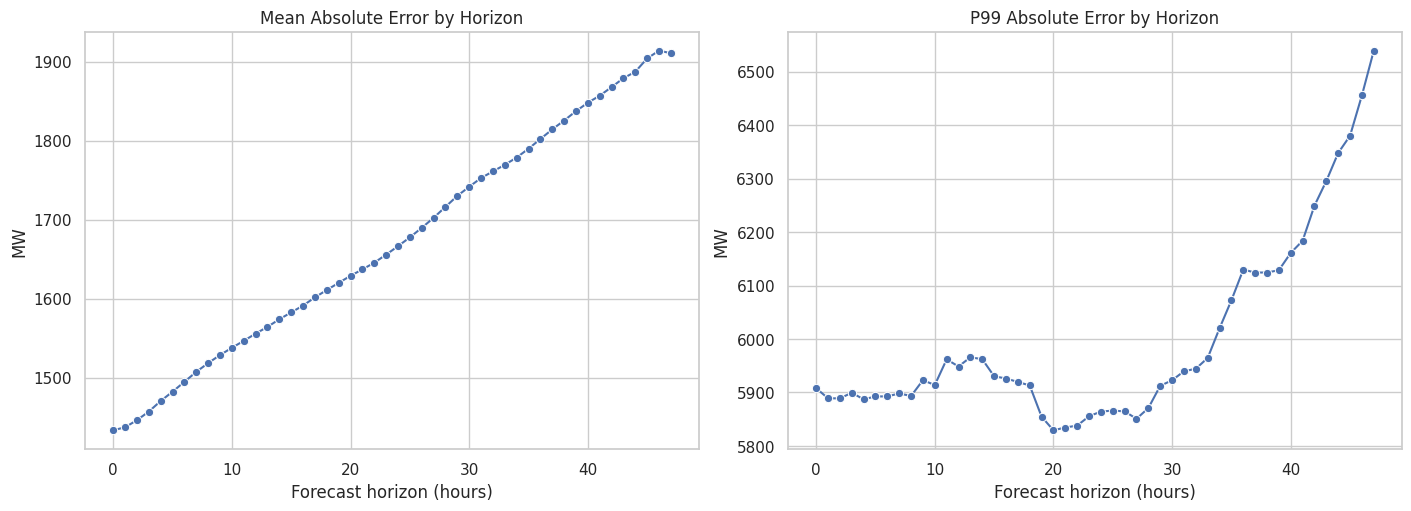

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.lineplot(
    data=horizon_summary,
    x="horizon",
    y="mean_abs_error_mw",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Mean Absolute Error by Horizon")
axes[0].set_xlabel("Forecast horizon (hours)")
axes[0].set_ylabel("MW")
sns.lineplot(
    data=horizon_summary,
    x="horizon",
    y="p99_abs_error_mw",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("P99 Absolute Error by Horizon")
axes[1].set_xlabel("Forecast horizon (hours)")
axes[1].set_ylabel("MW")
plt.show()


## Error by time of day

This view checks whether some delivery hours are materially harder
to predict than others.


In [14]:
hour_summary = (
    joined.groupby("hour")
    .agg(
        sample_count=("target_time", "size"),
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
        p99_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.99)),
    )
    .reset_index()
)
hour_summary


,hour,sample_count,mean_abs_error_mw,median_abs_error_mw,p99_abs_error_mw
0,0,18028,"1,731.21","1,277.00","5,981.87"
1,1,18425,"1,777.85","1,334.00","6,189.00"
2,2,18822,"1,805.49","1,367.00","6,185.00"
3,3,18848,"1,846.81","1,396.00","6,231.00"
4,4,18826,"1,880.41","1,426.00","6,377.00"
5,5,18666,"1,848.35","1,412.50","6,469.00"
6,6,18434,"1,820.87","1,392.00","6,379.68"
7,7,18832,"1,774.82","1,383.50","6,234.04"
8,8,18858,"1,684.70","1,296.00","5,920.00"
9,9,18832,"1,648.39","1,276.00","6,358.00"


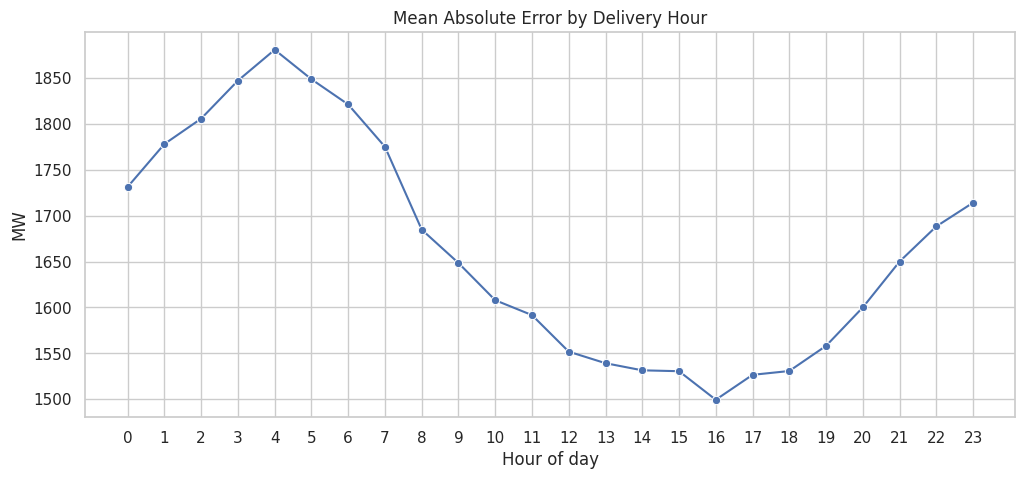

In [15]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=hour_summary, x="hour", y="mean_abs_error_mw", marker="o")
plt.title("Mean Absolute Error by Delivery Hour")
plt.xlabel("Hour of day")
plt.ylabel("MW")
plt.xticks(range(24))
plt.show()


## Interpretation checklist

Use the computed tables and plots above to answer:
- Is there a material signed bias overall?
- How quickly does error grow with horizon?
- Which hours of day are the least reliable?
- Is the tail risk small enough for your intended operational use?
